In [24]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

import matplotlib.pyplot as plt
from tqdm import tqdm

In [25]:
DEVICE = torch.device("mps")
T = 10
BATCH_SIZE=64

In [45]:
class SumDataset(Dataset):
    def __init__(self, epoch_size: int = 10_000, T: int = 10):
        self.epoch_size = epoch_size
        self.T = T
    
    def _generate_one(self):
        x = torch.randint(0, 2, size=(self.T, 1), dtype=torch.float32)
        y = torch.cumsum(x, 0)
        return (x, y)
        
    def __getitem__(self, _) -> torch.Tensor:
        return self._generate_one()
    
    def __len__(self):
        return self.epoch_size

ds_train = SumDataset(10_000, T)
ds_test = SumDataset(1_000, T)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

In [29]:
class RNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        # expect (B, T, 1)
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, h_t = self.rnn(x) # h_t not needed
        return self.fc(out)
        

In [44]:


def train(model, dl, epochs=10, lr=1e-3):
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.MSELoss()

    pbar = tqdm(range(epochs))
    losses = []
    model.train()
    for _ in pbar:
        avg_loss = 0
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
        
            optim.zero_grad()
            y_pred = model.forward(x)
            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()
            
            avg_loss += loss * x.size(0)
        avg_loss /= len(dl.dataset)
        pbar.set_postfix({"avg_loss": avg_loss.item()})
        losses.append(avg_loss.detach().cpu())

    plt.plot(losses)

def get_test_loss(model, dl_test):
    
    loss_fn = nn.MSELoss()
    model.eval()
    total_loss = 0
    for x, y in dl_test:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        
        y_pred = model.forward(x)
        loss = loss_fn(y_pred, y)
        total_loss += loss * x.size(0)
    return total_loss / len(dl_test.dataset)

def pretty_eval(model, ds_cls, T: int = 10):
    fig, axs = plt.subplots(4, 4)
    axs = axs.flatten()
    fig.set_size_inches(10, 10)
    ds = ds_cls(16, T=T)
    model.eval()
    for i in range(16):
        x, y = ds[i]
        x = x.to(DEVICE)
        y_pred = model.forward(x)
        
        ax = axs[i]
        ax.plot(y, label='Actual')
        ax.plot(y_pred.detach().cpu(), label='Predicted')
    
    ax.legend() # just one :)
    plt.show()
        

seems to do quite well 100 epochs on T = 10

```
100%|██████████| 100/100 [00:42<00:00,  2.37it/s, avg_loss=0.000197]
test loss: 0.00019233471539337188
```

100%|██████████| 100/100 [00:42<00:00,  2.37it/s, avg_loss=0.000197]

test loss: 0.00019233471539337188


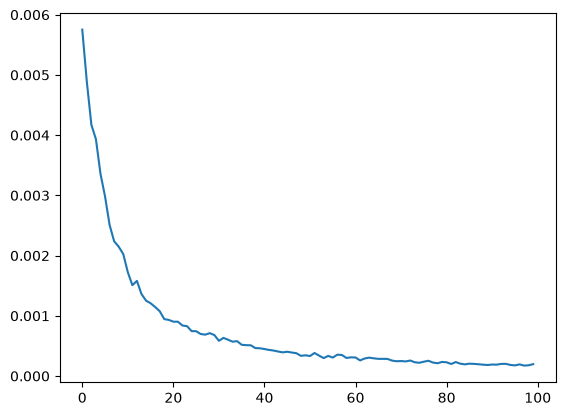

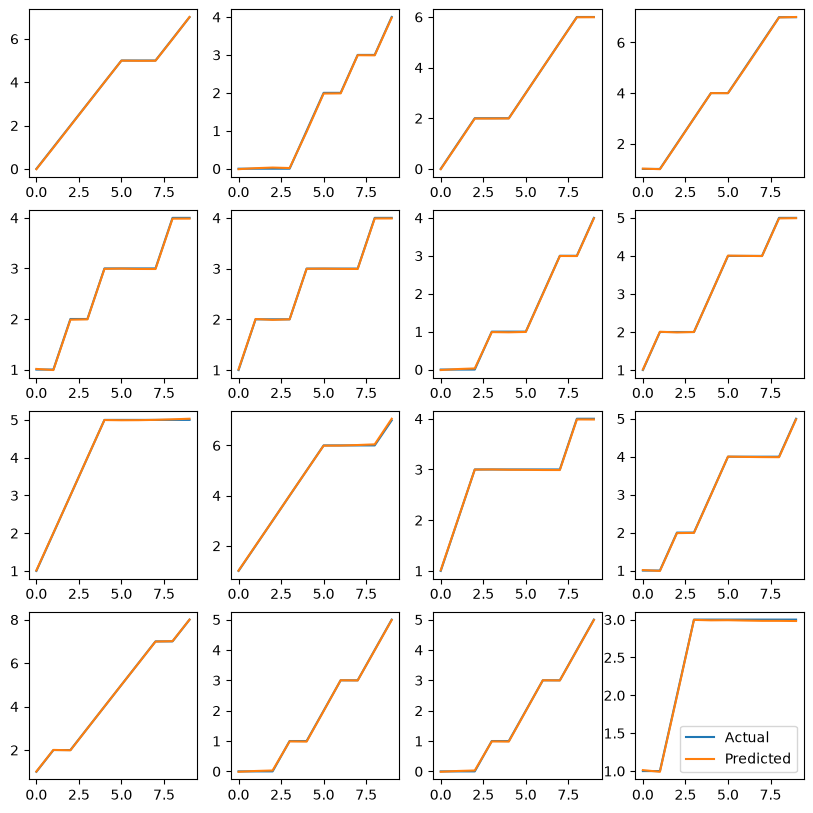

In [42]:
model = RNNModel().to(DEVICE)

train(model, dl_train, 100)
test_loss = get_test_loss(model, dl_test)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, SumDataset)


Failed on 50

```
100%|██████████| 100/100 [02:07<00:00,  1.28s/it, avg_loss=51.5]
test loss: 51.74979019165039
```

100%|██████████| 100/100 [02:07<00:00,  1.28s/it, avg_loss=51.5]


test loss: 51.74979019165039


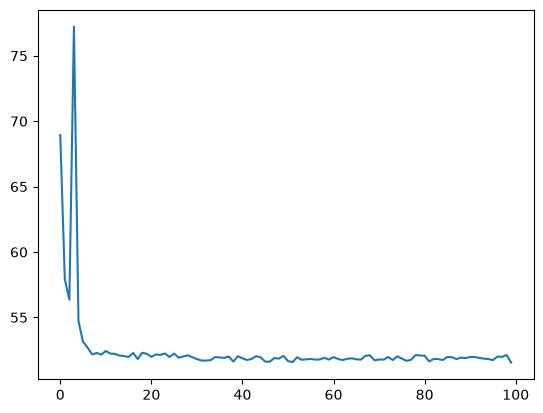

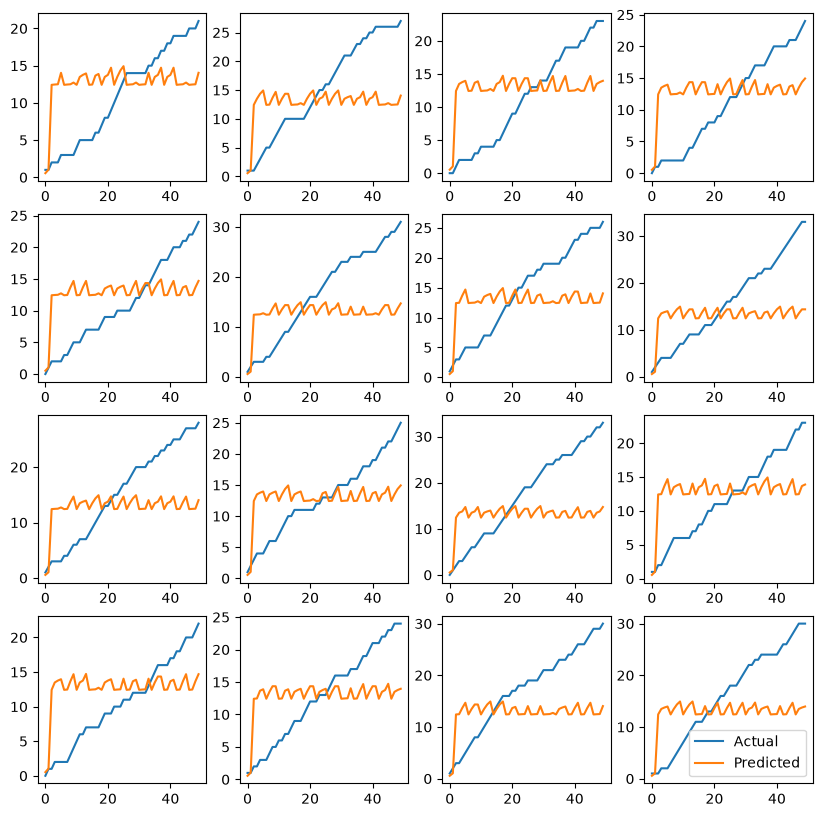

In [43]:
model = RNNModel().to(DEVICE)

# Now we try bigger, T=50
ds_train_50 = SumDataset(10_000, 50)
ds_test_50 = SumDataset(1_000, 50)
dl_train_50 = DataLoader(ds_train_50, batch_size=BATCH_SIZE, shuffle=True)
dl_test_50 = DataLoader(ds_test_50, batch_size=BATCH_SIZE, shuffle=False)

train(model, dl_train_50, 100)
test_loss = get_test_loss(model, dl_test_50)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, SumDataset, 50)


## Parity


Almost looks like grokking! see the chart 

```
------
       |
        |
         |
          ________________
```

```
100%|██████████| 100/100 [00:44<00:00,  2.24it/s, avg_loss=9.17e-6]
test loss: 1.1706322766258381e-05
```

In [46]:
class ParityDataset(Dataset):
    def __init__(self, epoch_size: int = 10_000, T: int = 10):
        self.epoch_size = epoch_size
        self.T = T
    
    def _generate_one(self):
        x = torch.randint(0, 2, size=(self.T, 1), dtype=torch.float32)
        y = torch.cumsum(x, 0) % 2
        return (x, y)
        
    def __getitem__(self, _) -> torch.Tensor:
        return self._generate_one()
    
    def __len__(self):
        return self.epoch_size

ds_train = ParityDataset(10_000, T)
ds_test = ParityDataset(1_000, T)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 100/100 [00:44<00:00,  2.24it/s, avg_loss=9.17e-6]

test loss: 1.1706322766258381e-05


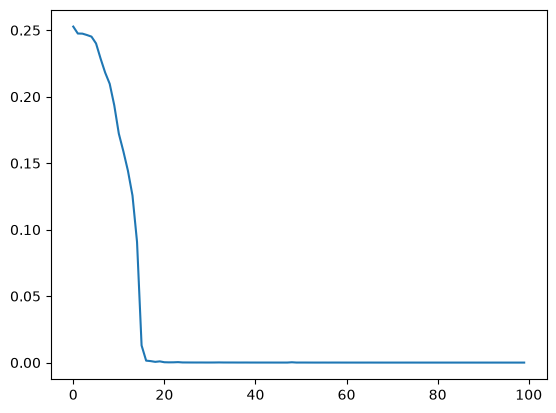

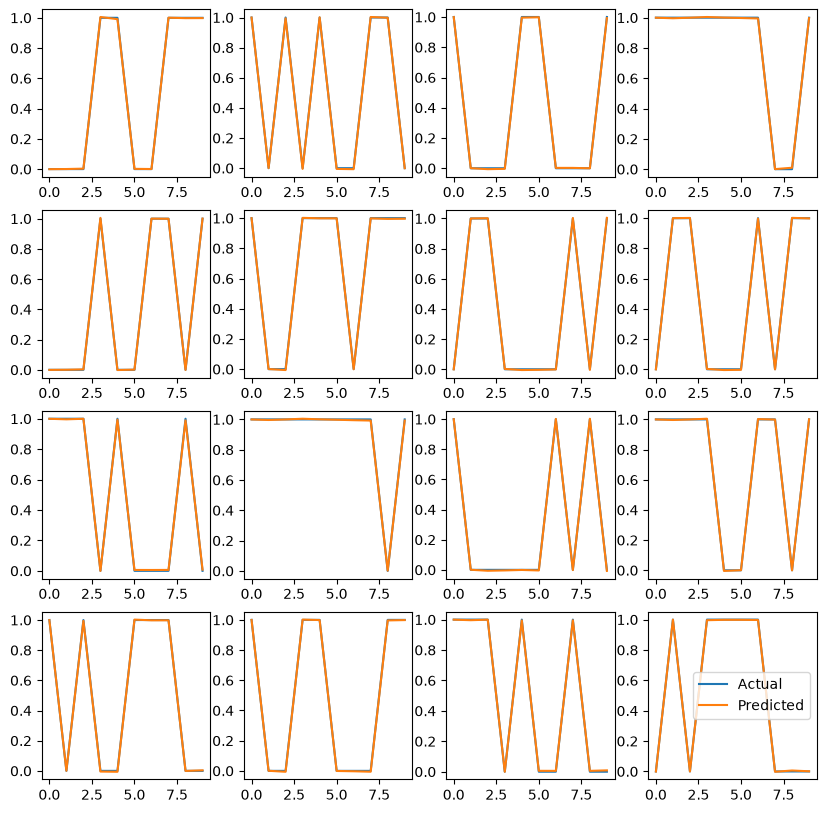

In [48]:
model = RNNModel().to(DEVICE)
train(model, dl_train, 100, lr=1e-3 * 16)
test_loss = get_test_loss(model, dl_test)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, ParityDataset)

t = 50 is interesting

If we train on T=50 then poor:

```
100%|██████████| 100/100 [02:06<00:00,  1.27s/it, avg_loss=0.223]
test loss: 0.22250255942344666
```

But if we train on T=10, then eval on T=50 – it does better!

```
100%|██████████| 100/100 [00:46<00:00,  2.16it/s, avg_loss=6.99e-6]
test loss: 1.497681387263583e-05
```

100%|██████████| 100/100 [00:46<00:00,  2.16it/s, avg_loss=6.99e-6]

test loss: 1.497681387263583e-05


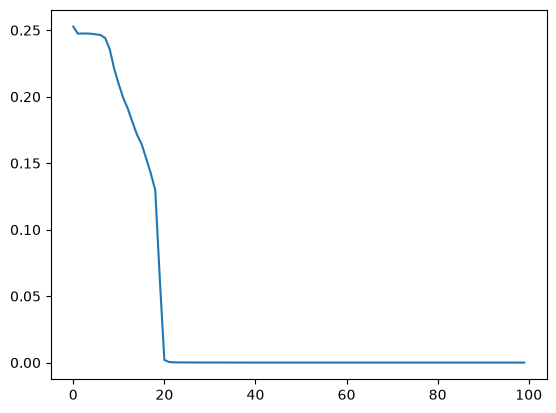

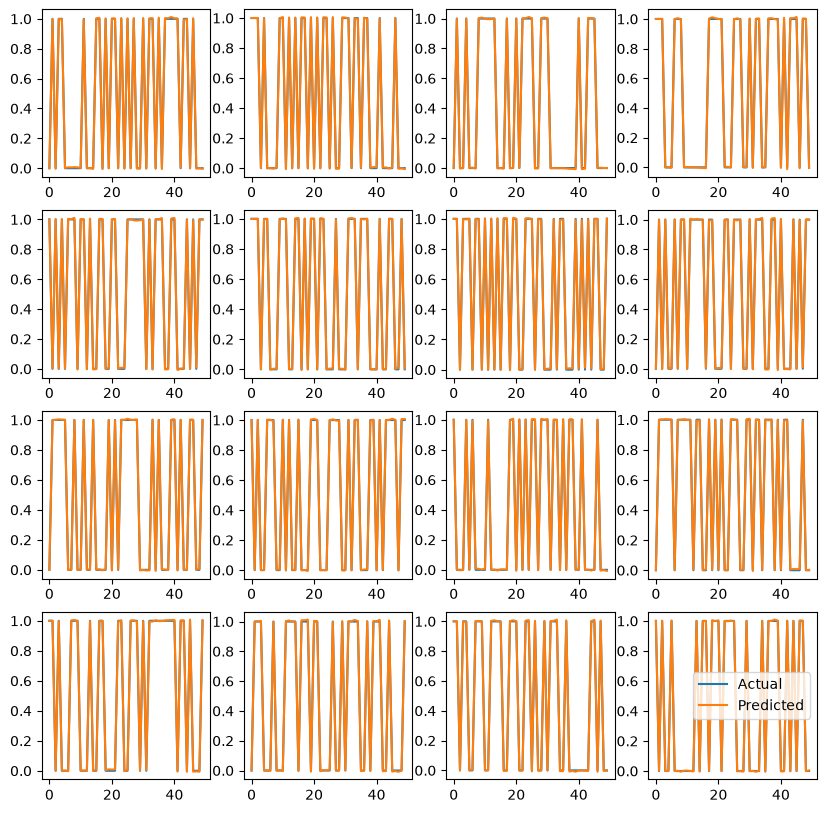

In [51]:
# how about t = 50?

ds_train_50 = ParityDataset(10_000, 10)
ds_test_50 = ParityDataset(1_000, 50)
dl_train_50 = DataLoader(ds_train_50, batch_size=BATCH_SIZE, shuffle=True)
dl_test_50 = DataLoader(ds_test_50, batch_size=BATCH_SIZE, shuffle=False)

model = RNNModel().to(DEVICE)
train(model, dl_train_50, 100, lr=1e-3 * 16)
test_loss = get_test_loss(model, dl_test_50)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, ParityDataset, 50)

## LSTM time

Is totally capable of the T=50 summation problem 

```
100%|██████████| 100/100 [00:43<00:00,  2.30it/s, avg_loss=0.00334]
test loss: 0.003013632260262966
```

In [52]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        # expect (B, T, 1)
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, 1)
        
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x) # h_n, c_n not needed
        return self.fc(out)
        

100%|██████████| 100/100 [00:43<00:00,  2.30it/s, avg_loss=0.00334]


test loss: 0.003013632260262966


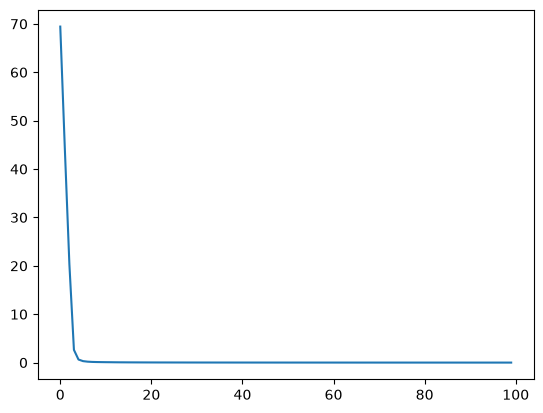

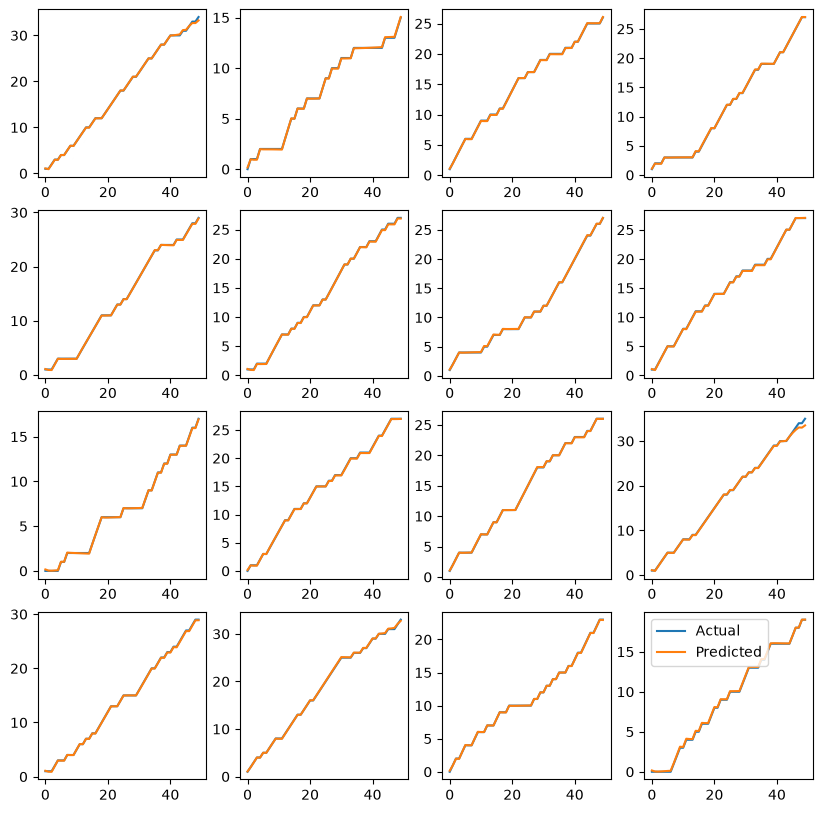

In [53]:
model = LSTMModel().to(DEVICE)

# Now we try bigger, T=50
ds_train_50 = SumDataset(10_000, 50)
ds_test_50 = SumDataset(1_000, 50)
dl_train_50 = DataLoader(ds_train_50, batch_size=BATCH_SIZE, shuffle=True)
dl_test_50 = DataLoader(ds_test_50, batch_size=BATCH_SIZE, shuffle=False)

train(model, dl_train_50, 100)
test_loss = get_test_loss(model, dl_test_50)
print(f'test loss: {test_loss.item()}')
pretty_eval(model, SumDataset, 50)


## Part B, copy/delay problem

In [143]:
class CopyDataset(Dataset):
    def __init__(self, epoch_size: int = 10_000, k: int = 5, vocab_size: int = 8, sequence_len: int = 5):
        self.epoch_size = epoch_size
        self.k = k
        
        # vocab
        self.vocab_size = vocab_size
        self.sequence_len = sequence_len
        
        self.idx_to_char = {i:chr(ord('A') + i) for i in range(self.vocab_size)}
        self.idx_to_char[self.vocab_size] = '_'
        
        
    def _generate_example(self) -> tuple[torch.Tensor, torch.Tensor]:
        # input
        seq = torch.zeros(self.sequence_len, self.vocab_size + 1)
        chars = torch.randint(0, self.vocab_size, (self.sequence_len,))
        seq[[i for i in range(self.sequence_len)], chars] = 1  # one hot encoding
        
        # output
        delay = torch.zeros(self.k, self.vocab_size + 1)
        delay[:, -1] = 1  # blank token
        
        x = torch.cat((seq, delay))
        y = torch.cat((torch.full((self.k,), self.vocab_size), chars))  # indexes
        return (x, y)
        
    
    def __len__(self):
        return self.epoch_size
    
    def __getitem__(self, _):
        return self._generate_example()
    
    def seq_to_str(self, seq):
        return ''.join([self.idx_to_char[x] for x in seq])

In [144]:
class RNNCopyModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=vocab_size + 1,
            hidden_size=16,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(16, vocab_size + 1)
    
    def forward(self, x):
        out, h_n = self.rnn(x)
        return self.fc(out)

In [145]:
ds_train = CopyDataset(10000, k=2, vocab_size=8, sequence_len=3)
ds_test = CopyDataset(1000, k=2, vocab_size=8, sequence_len=3)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

In [146]:
ds_train._generate_example()

(tensor([[0., 0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0., 0., 0., 0., 1.]]),
 tensor([8, 8, 4, 4, 7]))

In [156]:
c = torch.zeros((64, 5, 9))
c.shape
c.reshape(-1, 9).shape

torch.Size([320, 9])

In [219]:
def train_copy(model: nn.Module, dl: DataLoader, lr: float, epochs: int, use_adam: bool = False):
    loss_fn = nn.CrossEntropyLoss()
    if use_adam:
        optim = torch.optim.AdamW(model.parameters(), lr=lr)
    else:
        optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    pbar = tqdm(range(epochs))
    losses = []
    
    model.train()
    for _ in pbar:
        avg_loss = 0
        for x, y in dl:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            
            optim.zero_grad()
            y_pred = model.forward(x)
            
            # Collapse (B, T, C) -> (B*T, C)
            y_pred = y_pred.reshape(-1, 9)
            # Collapse (B, T) -> (B*T)
            y = y.reshape(-1)

            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()

            avg_loss += loss * x.size(0)
        avg_loss /= len(dl.dataset)
        avg_loss = avg_loss.detach().cpu().item()
        losses.append(avg_loss)
        pbar.set_postfix({'avg_loss': avg_loss})
    
    plt.plot(losses)
    
def evaluate_copy(model, dl):
    loss_fn = nn.CrossEntropyLoss()
    avg_loss = 0
    correct_count = 0
    
    model.eval()
    for x, y in dl:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        
        y_pred = model.forward(x)
        # Collapse (B, T, C) -> (B*T, C)
        y_pred = y_pred.reshape(-1, 9)
        # Collapse (B, T) -> (B*T)
        y = y.reshape(-1)
        
        loss = loss_fn(y_pred, y)
        
        # acc
        y_pred_idx = y_pred.argmax(dim=1)
        correct_count += (y_pred_idx == y).sum()
        
        avg_loss += loss * x.size(0)
    avg_loss /= len(dl.dataset)
    t = x.shape[1]
    acc = correct_count / (len(dl.dataset) * t)
    print(f'avg_loss: {avg_loss}')
    print(f'acc: {acc}')
    
    
def evaluate_copy_pretty(model, k=2, L=3):
    ds = CopyDataset(10000, k, 8, L)
    model.eval()
    for i in range(8):
        x, y = ds._generate_example()
        x = x.to(DEVICE)
        y_pred = model.forward(x)
        y_pred_idx = y_pred.argmax(1)
        
        pred_seq = ds.seq_to_str(y_pred_idx.cpu().numpy())
        true_seq = ds.seq_to_str(y.numpy())
        print(f'----------------\n{pred_seq}\n{true_seq}')
        

Train fine w/ k=2, L3

```
100%|██████████| 100/100 [00:42<00:00,  2.37it/s, avg_loss=0.000197]
test loss: 0.00019233471539337188


100%|██████████| 100/100 [02:07<00:00,  1.28s/it, avg_loss=51.5]
test loss: 51.74979019165039

100%|██████████| 100/100 [00:44<00:00,  2.24it/s, avg_loss=9.17e-6]
test loss: 1.1706322766258381e-05


100%|██████████| 100/100 [00:46<00:00,  2.16it/s, avg_loss=6.99e-6]
test loss: 1.497681387263583e-05





100%|██████████| 100/100 [00:43<00:00,  2.30it/s, avg_loss=0.00334]
test loss: 0.003013632260262966
100%|██████████| 10/10 [00:03<00:00,  3.08it/s, avg_loss=0.0281]
avg_loss: 0.025225795805454254
acc: 1.0
----------------
__BCD
__BCD
----------------
__HHG
__HHG
----------------
__CAG
__CAG
----------------
__AFD
__AFD
----------------
__FBB
__FBB
----------------
__CFA
__CFA
----------------
__BHH
__BHH
----------------
__DCF
__DCF

```

100%|██████████| 10/10 [00:03<00:00,  3.08it/s, avg_loss=0.0281]

avg_loss: 0.025225795805454254
acc: 1.0
----------------
__BCD
__BCD
----------------
__HHG
__HHG
----------------
__CAG
__CAG
----------------
__AFD
__AFD
----------------
__FBB
__FBB
----------------
__CFA
__CFA
----------------
__BHH
__BHH
----------------
__DCF
__DCF


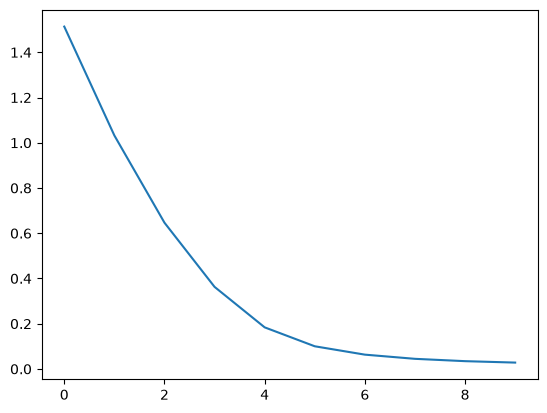

In [186]:
model = RNNCopyModel(8).to(DEVICE)
train_copy(model, dl_train, 1e-3*16, 10)
evaluate_copy(model, dl_test)
evaluate_copy_pretty(model, k=2, L=3)

at l =5 , k =5 , rnn training becomes unstable. observerd lots of spikes in train loss graph. avg loss not great, but does OK in pretty eval w/ ~99% acc. but this is clearly nearing the limit

100%|██████████| 100/100 [00:44<00:00,  2.25it/s, avg_loss=0.908]

avg_loss: 0.10690990090370178
acc: 0.9889000058174133
----------------
_____HGDGG
_____HGDGG
----------------
_____HHFBC
_____HHFBC
----------------
_____GCDDG
_____GCDDG
----------------
_____GBHFE
_____GBHFE
----------------
_____CCDAH
_____CCDAH
----------------
_____CFACD
_____CFACD
----------------
_____DDGHB
_____DDGHB
----------------
_____DHFHA
_____HHFHA


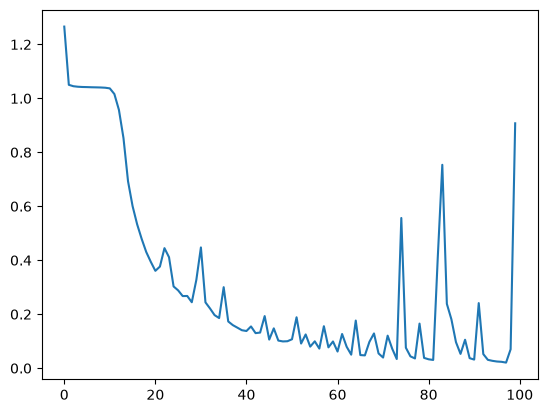

In [188]:
# now go 5, 5

ds_train = CopyDataset(10000, k=5, vocab_size=8, sequence_len=5)
ds_test = CopyDataset(1000, k=5, vocab_size=8, sequence_len=5)
dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

model = RNNCopyModel(8).to(DEVICE)
train_copy(model, dl_train, 1e-3*16, 100)
evaluate_copy(model, dl_test)
evaluate_copy_pretty(model, k=5, L=5)

In [ ]:
class LSTMCopyModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=vocab_size + 1, hidden_size=16, num_layers=1, batch_first=True
        )
        self.fc = nn.Linear(16, vocab_size + 1)

    def forward(self, x):
        out, (_, _) = self.lstm(x)
        return self.fc(out)

training LSTM was slower. at 1e-3 * 16 (same as rnn), was quite underfit. but it was stable!

bumping LR for lstm to 1e-3 * 64 sees stable training and better test result than RNN

100%|██████████| 100/100 [00:37<00:00,  2.69it/s, avg_loss=0.0208]

avg_loss: 0.026862068101763725
acc: 0.9922000169754028
----------------
_____BFGAF
_____BFGAF
----------------
_____BCHEH
_____BCHEH
----------------
_____FFCHF
_____FFCHF
----------------
_____AHGFE
_____AHGFE
----------------
_____BCCCG
_____BCCCG
----------------
_____BABCB
_____BABCB
----------------
_____DEAHG
_____DEAHG
----------------
_____HBFAG
_____HBFAG


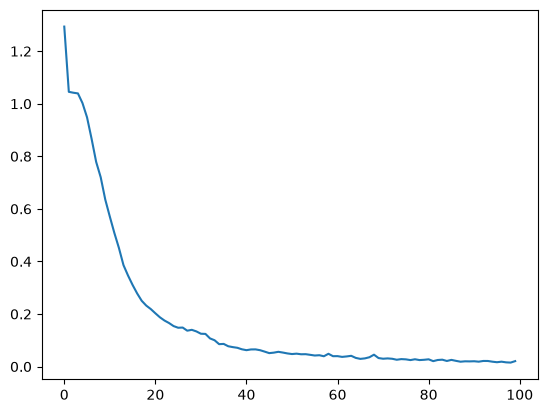

In [193]:
model = LSTMCopyModel(8).to(DEVICE)
train_copy(model, dl_train, 1e-3 * 64, 100)
evaluate_copy(model, dl_test)
evaluate_copy_pretty(model, 5, 5)
    

## quick try at k=20 with bigger models

In [ ]:
class RNNCopyModelLarge(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=vocab_size + 1, hidden_size=64, num_layers=3, batch_first=True
        )
        self.fc = nn.Linear(64, vocab_size + 1)

    def forward(self, x):
        out, h_n = self.rnn(x)
        return self.fc(out)


class LSTMCopyModelLarge(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=vocab_size + 1,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
        )
        self.fc = nn.Linear(64, vocab_size + 1)

    def forward(self, x):
        out, (_, _) = self.lstm(x)
        return self.fc(out)

In [216]:

ds_train_5 = CopyDataset(10000, k=5, vocab_size=8, sequence_len=5)
ds_test_5 = CopyDataset(1000, k=5, vocab_size=8, sequence_len=5)
dl_train_5 = DataLoader(ds_train_5, batch_size=BATCH_SIZE, shuffle=True)
dl_test_5 = DataLoader(ds_test_5, batch_size=BATCH_SIZE, shuffle=False)

# now go k=20 T=5

ds_train_20 = CopyDataset(10000, k=20, vocab_size=8, sequence_len=5)
ds_test_20 = CopyDataset(1000, k=20, vocab_size=8, sequence_len=5)
dl_train_20 = DataLoader(ds_train_20, batch_size=BATCH_SIZE, shuffle=True)
dl_test_20 = DataLoader(ds_test_20, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 100/100 [00:43<00:00,  2.30it/s, avg_loss=0.0568]


avg_loss: 0.057485707104206085
acc: 0.9801200032234192
----------------
____________________AEBFC
____________________AEBFC
----------------
____________________GBFDD
____________________GGFDD
----------------
____________________DACFD
____________________DACFD
----------------
____________________DGBFA
____________________DGBFA
----------------
____________________HDFEE
____________________HDFEE
----------------
____________________HBCAE
____________________HBCAE
----------------
____________________BEAAG
____________________BEAHG
----------------
____________________AGEGB
____________________AGEGB


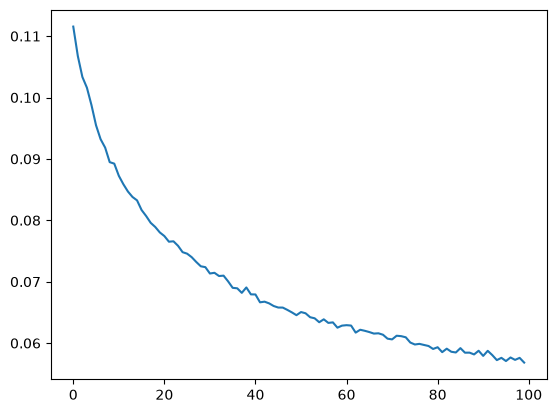

In [304]:
rnn_model = RNNCopyModelLarge(8).to(DEVICE)
train_copy(model, dl_train_20, 1e-3*16, 100)
evaluate_copy(model, dl_test_20)
evaluate_copy_pretty(model, k=20, L=5)

100%|██████████| 100/100 [00:32<00:00,  3.04it/s, avg_loss=0.000854]


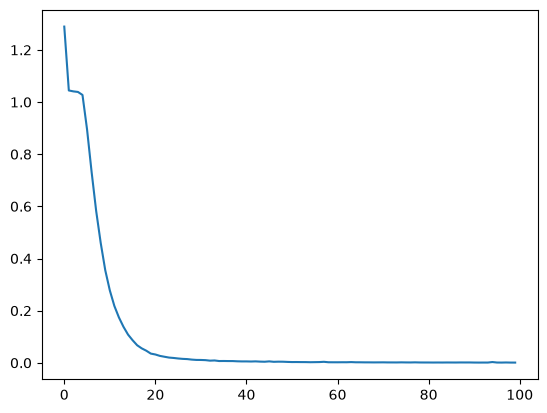

100%|██████████| 100/100 [00:45<00:00,  2.18it/s, avg_loss=0.19]

avg_loss: 0.19102539122104645
acc: 0.921720027923584
----------------
____________________BFBAB
____________________BFFAB
----------------
____________________CABHC
____________________CABHC
----------------
____________________EEAAF
____________________EHAGF
----------------
____________________AHHHH
____________________AHDDG
----------------
____________________BHFFF
____________________BHFHE
----------------
____________________AHCCC
____________________AECCC
----------------
____________________CHCBH
____________________CHCBG
----------------
____________________HHHHH
____________________HHDEH


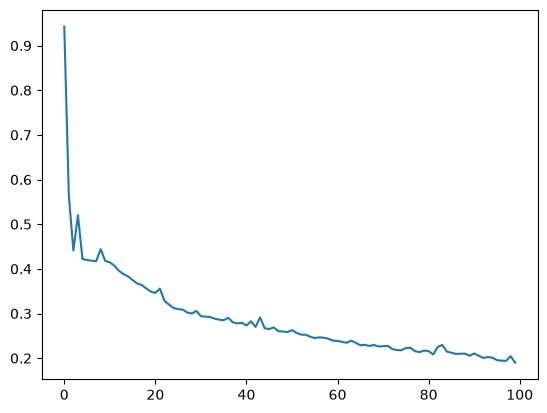

In [305]:
model = LSTMCopyModelLarge(8).to(DEVICE)
train_copy(model, dl_train_5, 1e-3*64, 100)
plt.show()
train_copy(model, dl_train_20, 1e-3*64, 100)
evaluate_copy(model, dl_test_20)
evaluate_copy_pretty(model, k=20, L=5)

100%|██████████| 100/100 [00:38<00:00,  2.60it/s, avg_loss=0.00121]

avg_loss: 0.00855835247784853
acc: 0.9976400136947632
----------------
____________________GADCA
____________________GADCA
----------------
____________________EEBEC
____________________EEBEC
----------------
____________________BHHEE
____________________BHHEE
----------------
____________________DFBGH
____________________DFBGH
----------------
____________________BGGEB
____________________BGGEB
----------------
____________________CEEBC
____________________CEEBC
----------------
____________________BAHFC
____________________BAHFC
----------------
____________________CFBDE
____________________CCBDE


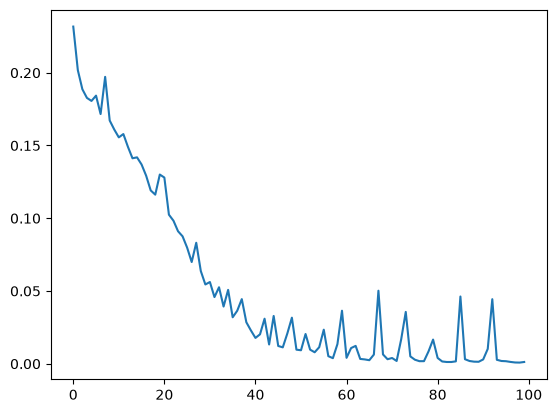

In [306]:
# now try adam
lstm_model = LSTMCopyModelLarge(8).to(DEVICE)
train_copy(model, dl_train_20, 1e-3*8, 100, True)
evaluate_copy(model, dl_test_20)
evaluate_copy_pretty(model, k=20, L=5)

## Grad inspection

In [386]:
def plot_gradients(model: RNNCopyModel, dl: DataLoader):
    
    # in case something went wrong
    rnn_model.rnn._backward_hooks.clear()
    
    ## Register some hooks
    grads = []
    def hook(model, input, output):
        grad = output[0].detach().cpu().flatten().abs()
        grads.append(grad)
        # print(model)
        # grad = grad.detach().cpu().flatten().abs()
        # grads.append(grad)
    # handle = model.rnn.register_backward_hook(hook)
    handle = model.rnn.register_full_backward_hook(hook)
    
    ## Run forwards, aggregate gradients
    optim = torch.optim.SGD(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    
    model.train()
    for x, y in dl:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        
        optim.zero_grad()
        y_pred = model.forward(x)
        
        y_pred = y_pred.reshape(-1, 9)
        y = y.reshape(-1)
        
        loss = loss_fn(y_pred, y)
        loss.backward()
        # no step
        
    
    ## plot
    print(grads[0].mean())
    plt.hist(grads, bins=50)
    plt.show()
    
    ## Deregister hooks
    handle.remove()
    
def get_mean_abs_grad(model: RNNCopyModel, dl: DataLoader):
    
    # in case something went wrong
    rnn_model.rnn._backward_hooks.clear()
    
    ## Register some hooks
    grads = []
    def hook(model, input, output):
        grad = output[0].detach().cpu().flatten().abs()
        grads.append(grad)
        # print(model)
        # grad = grad.detach().cpu().flatten().abs()
        # grads.append(grad)
    # handle = model.rnn.register_backward_hook(hook)
    handle = model.rnn.register_full_backward_hook(hook)
    
    ## Run forwards, aggregate gradients
    optim = torch.optim.SGD(model.parameters())
    loss_fn = nn.CrossEntropyLoss()
    
    model.train()
    for x, y in dl:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        
        optim.zero_grad()
        y_pred = model.forward(x)
        
        y_pred = y_pred.reshape(-1, 9)
        y = y.reshape(-1)
        
        loss = loss_fn(y_pred, y)
        loss.backward()
        # no step
        
    ## Deregister hooks
    handle.remove()
    
    return grads[0].mean()

<sys>:0: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Text(0.5, 1.0, 'Vanishing Gradient – RNN')

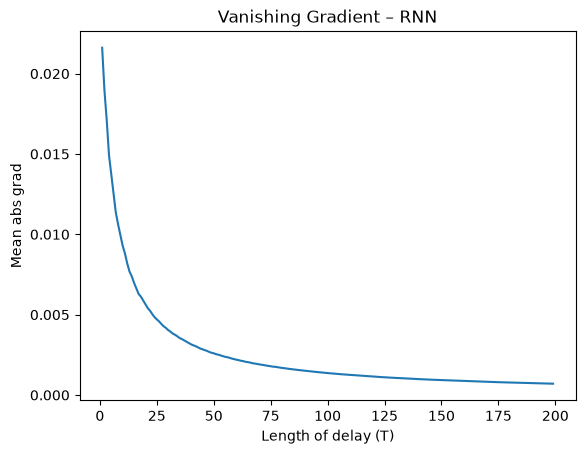

In [388]:
model2 = RNNCopyModel(8).to(DEVICE)

t = torch.arange(1, 200, 1)
grads = []
for i in t:
    small_dataset = CopyDataset(1, i, 8, 5)
    small_dl = DataLoader(small_dataset, 10)
    grads.append(get_mean_abs_grad(model2, small_dl))

plt.plot(t, grads)
plt.ylabel("Mean abs grad")
plt.xlabel("Length of delay (T)")
plt.title("Vanishing Gradient – RNN")


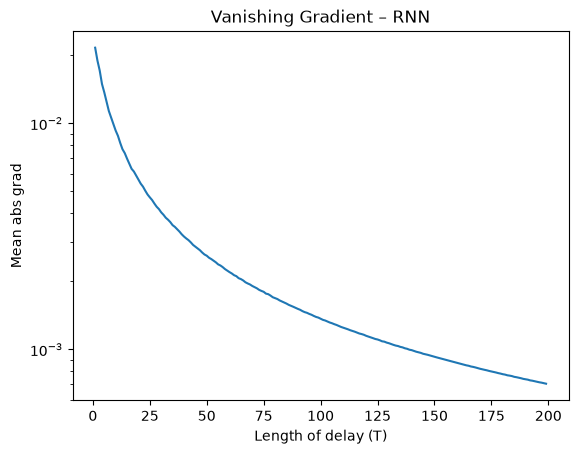

In [390]:
plt.plot(t, grads)
plt.ylabel("Mean abs grad")
plt.xlabel("Length of delay (T)")
plt.title("Vanishing Gradient – RNN")
plt.yscale('log')

In [486]:
a = torch.tensor([[1], [2]], dtype=torch.float32)
a.mean([0, 1])

tensor(1.5000)

In [535]:
def plot_gradients_v2(model: RNNCopyModel, dl: DataLoader, is_rnn: bool = True):
    
    ## Run forwards, aggregate gradients
    optim = torch.optim.SGD(model.parameters())
    weight = torch.ones(9).to(DEVICE)  # vocab
    weight[-1] = 0 # zero weight on delay token
    loss_fn = nn.CrossEntropyLoss(weight)
    
    model.train()
    # assume only 1 batch
    for x, y in dl:
        x = x.to(DEVICE).requires_grad_(True)
        y = y.to(DEVICE)
        
        optim.zero_grad()
        y_pred = model.forward(x)
        
        y_pred = y_pred.reshape(-1, 9)
        y = y.reshape(-1)
        loss = loss_fn(y_pred, y)
        loss.backward()
        # no step
        
        
    
    ## plot
    grads = x.grad.abs().mean([0, -1]).detach().cpu()
    plt.plot(torch.arange(0, grads.shape[0]), grads)
    plt.yscale('log')
    plt.show()
    

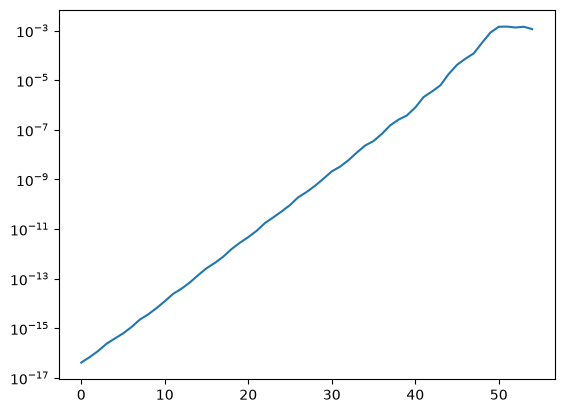

In [536]:
k = 50
t = 5
small_dataset = CopyDataset(10, k, 8, t)
small_dl = DataLoader(small_dataset, 10)
model2 = RNNCopyModel(8).to(DEVICE)
plot_gradients_v2(model2, small_dl)

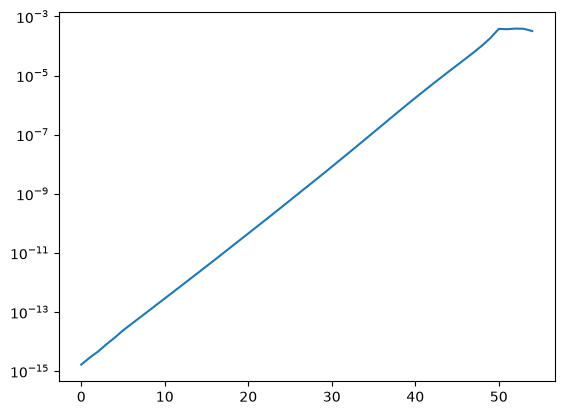

In [537]:
k = 50
t = 5
small_dataset = CopyDataset(10, k, 8, t)
small_dl = DataLoader(small_dataset, 10)
model3 = LSTMCopyModel(8).to(DEVICE)
plot_gradients_v2(model3, small_dl, False)

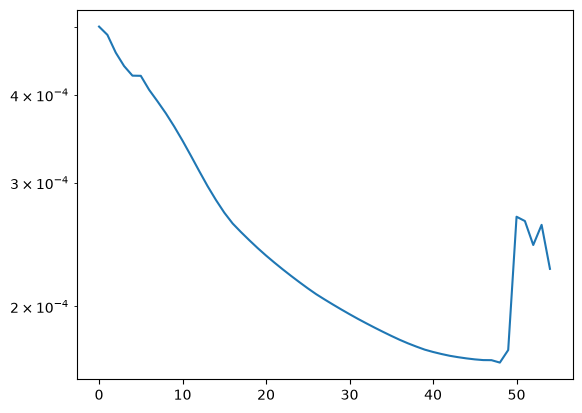

In [549]:
k = 50
t = 5
small_dataset = CopyDataset(10, k, 8, t)
small_dl = DataLoader(small_dataset, 10)
model4 = LSTMCopyModel(8).to(DEVICE)
with torch.no_grad():
    H = 16
    model4.lstm.bias_ih_l0[H:2*H].fill_(3.0)
    model4.lstm.bias_hh_l0[H:2*H].fill_(3.0)
plot_gradients_v2(model4, small_dl, False)
# model4.lstm.bias_ih_l0